Провести разведочный анализ данных о продажах кофейного автомата:

*  оценить качество и полноту данных,
*  изучить динамику транзакций и выручки,
*  определить структуру спроса,
*  выявить временные закономерности и аномалии,
*  сформулировать гипотезы для дальнейшего анализа.

## Краткое резюме результатов

* проанализировано 3 636 зарегистрированных операций за период с 1 марта 2024 года по 23 марта 2025 года; суммарная выручка составила 115 431,58 у. е.;
* максимальные месячные показатели среди полных месяцев зафиксированы в октябре 2024 года: 426 операций и 13 891,16 у. е. выручки;
* Americano with Milk лидирует по количеству операций — 824, а Latte по выручке — 27 866,30 у. е.;
* средняя сумма операции снизилась летом 2024 года одновременно с изменением структуры спроса и уровней карточных сумм по большинству напитков;
* пиковый час — 10:00–10:59; средняя дневная активность максимальна во вторник и минимальна в воскресенье;
* наличные операции составили 12,84% операций до 3 июня 2024 года и после этой даты в данных не встречаются;
* 41,4% идентификаторов карт встречаются повторно, и на них приходится 78,3% карточных операций.

Эти результаты описывают зарегистрированные операции. Датасет не содержит данных о прибыли, себестоимости, доступности автомата и причинах изменения сумм или способов оплаты, поэтому резюме не следует интерпретировать как доказательство причинных связей.

## 1. Загрузка и первичная проверка данных

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
df=pd.read_csv('../data/index_1.csv',parse_dates=['date','datetime'])
display(df.head())
print('----------------------')
df.info()
print('----------------------')
print(f'Начало сбора данных: {df['date'].min()}, конец сбора данных: {df['date'].max()}')
print('----------------------')

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


----------------------
<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[us]
 1   datetime     3636 non-null   datetime64[us]
 2   cash_type    3636 non-null   str           
 3   card         3547 non-null   str           
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   str           
dtypes: datetime64[us](2), float64(1), str(3)
memory usage: 287.9 KB
----------------------
Начало сбора данных: 2024-03-01 00:00:00, конец сбора данных: 2025-03-23 00:00:00
----------------------


In [3]:
missing_summary=pd.DataFrame({
    'missing_count':df.isna().sum(),
    'missing_procent':df.isna().mean().mul(100).round(2)
})

display(missing_summary)

duplicate_count=df.duplicated().sum()

print(f'Количество дубликатов: {duplicate_count}')

,missing_count,missing_procent
date,0,0.00
datetime,0,0.00
cash_type,0,0.00
card,89,2.45
money,0,0.00
coffee_name,0,0.00


Количество дубликатов: 0


In [4]:
df_null=df[df['card'].isna()]
print(f'Всего строк с null: {len(df_null)} из них с оплатой cash: {len(df_null[df_null['cash_type']=='cash'])}, c оплатой картой: {len(df_null[df_null['cash_type']=='card'])}')

Всего строк с null: 89 из них с оплатой cash: 89, c оплатой картой: 0


In [5]:
display(df['cash_type'].value_counts())
display(df['coffee_name'].value_counts())

cash_type
card    3547
cash      89
Name: count, dtype: int64

coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
Name: count, dtype: int64

In [6]:
calendar = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
missing_dates = calendar.difference(df['date'].unique())

missing_dates

DatetimeIndex(['2024-05-01', '2024-05-04', '2024-05-05', '2024-11-27',
               '2025-01-01', '2025-01-19', '2025-01-23'],
              dtype='datetime64[us]', freq=None)

In [7]:
date_mismatches = (
    df['date'] != df['datetime'].dt.normalize()
).sum()

date_mismatches


np.int64(0)

In [8]:
print(f'Минимальная сумма операции: {df["money"].min()}')
print(f'Максимальная сумма операции: {df["money"].max()}')
print(f'Нулевых или отрицательных сумм: {(df["money"] <= 0).sum()}')

Минимальная сумма операции: 18.12
Максимальная сумма операции: 40.0
Нулевых или отрицательных сумм: 0


Общий итог по загруженным данным:

* всего 3636 строк с 6 признаками
* пропущенные значения в 89 строках в полях card, они связаны с отсутствием номера карты при оплате наличными
* нет дубликатов
* некорректных дат (когда время транзакции не совпадает date) не обнаружено
* обнаружено 7 дней, по которым нет данных о транзакциях (по данным невозможно определить были ли это дни без продаж или это аномалии в сборе данных)
* нулевых или отрицательных сумм не обнаружено
* суммы операций находятся в диапазоне от 18.12 до 40.00

>  Для построения непрерывного временного ряда отсутствующим датам присваивается нулевое
>  количество зарегистрированных транзакций. Это техническое допущение: по данным нельзя
>  однозначно судить, что было в упомянутые дни.

## 2. Динамика транзакций и выручки

In [9]:
last_month_start = df['date'].max().to_period('M').start_time
complete_months_df = df[df['date'] < last_month_start]

Последний месяц наблюдений является неполным, поэтому он исключен из сравнения полных календарных месяцев.

In [10]:
monthly_sales = (
    complete_months_df
    .set_index('date')
    .resample('MS')
    .agg(
        transactions=('money', 'size'),
        revenue=('money', 'sum'),
        average_transaction=('money', 'mean')
    )
    .reset_index()
)

monthly_sales

,date,transactions,revenue,average_transaction
0,2024-03-01,206,7050.20,34.224272
1,2024-04-01,196,6720.56,34.288571
2,2024-05-01,267,9063.42,33.945393
3,2024-06-01,227,7758.76,34.179559
4,2024-07-01,237,6915.94,29.181181
5,2024-08-01,272,7613.84,27.992059
6,2024-09-01,344,9988.64,29.036744
7,2024-10-01,426,13891.16,32.608357
8,2024-11-01,259,8590.54,33.168108
9,2024-12-01,259,8237.74,31.805946


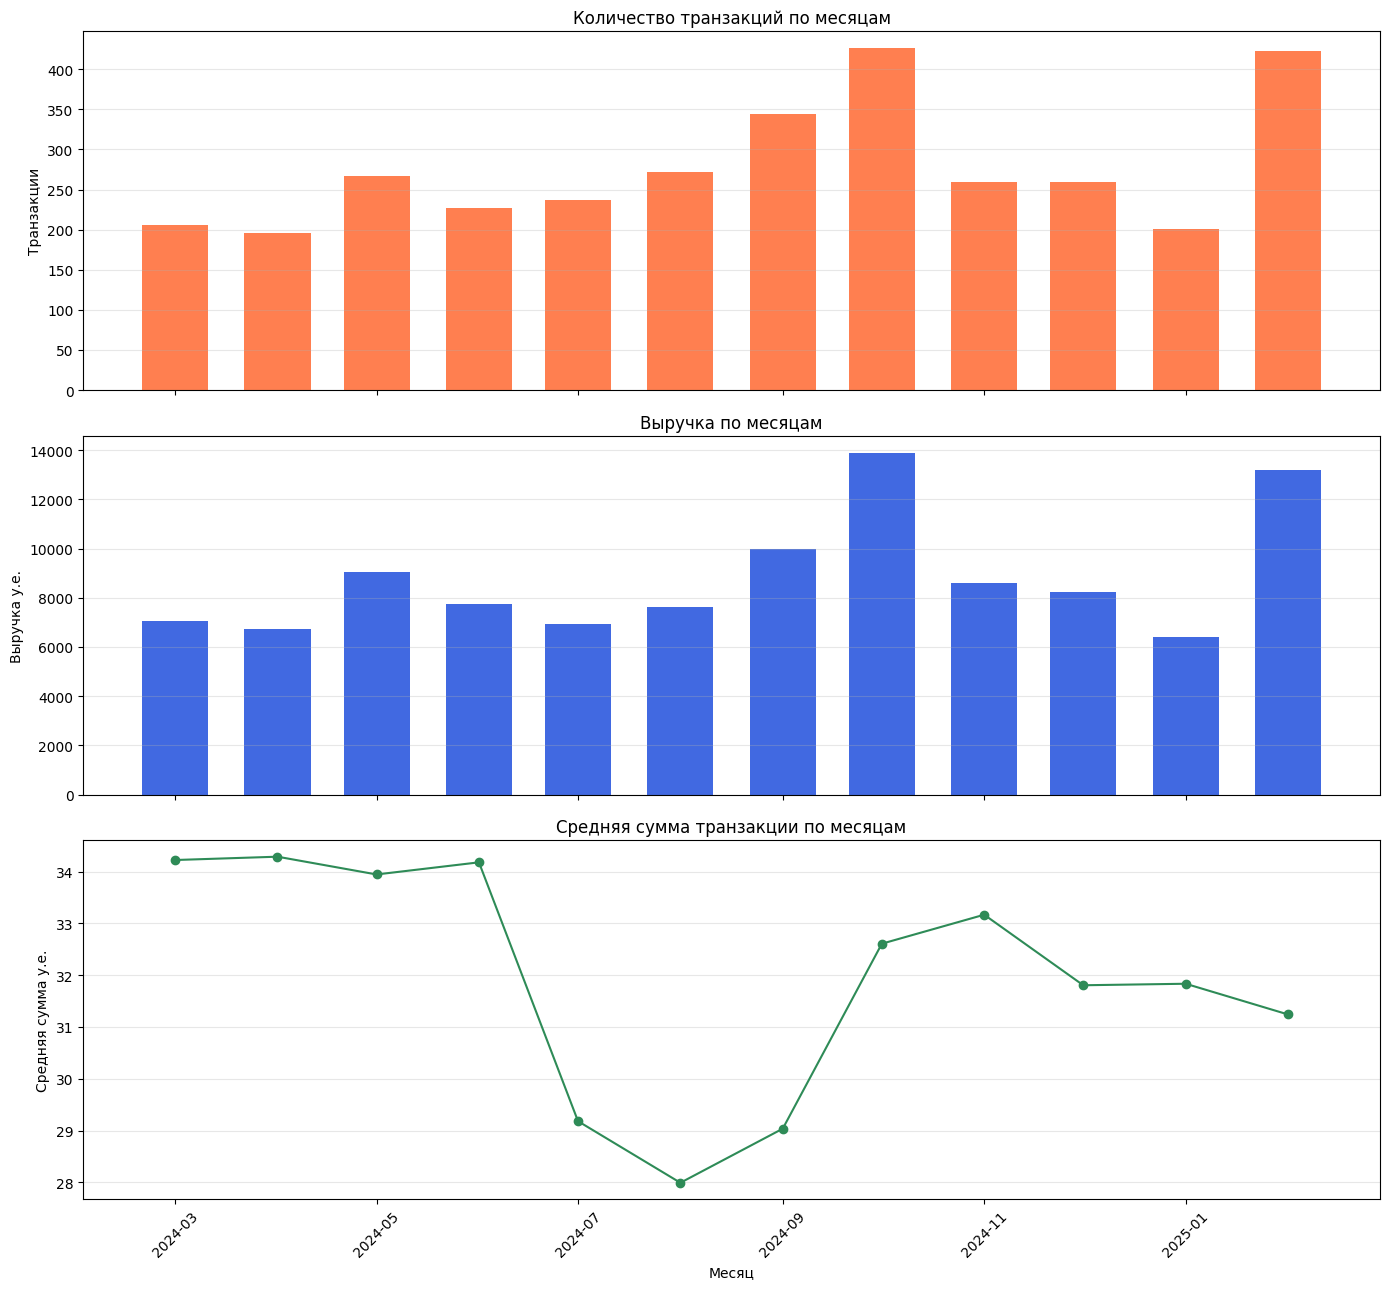

In [11]:
fig,axes=plt.subplots(3,1,figsize=(14,13),sharex=True)

axes[0].bar(monthly_sales['date'],monthly_sales['transactions'],width=20,color='coral')
axes[0].set_title('Количество транзакций по месяцам')
axes[0].set_ylabel('Транзакции')

axes[1].bar(monthly_sales['date'],monthly_sales['revenue'],width=20,color='royalblue')
axes[1].set_title('Выручка по месяцам')
axes[1].set_ylabel('Выручка у.е.')

axes[2].plot(monthly_sales['date'],monthly_sales['average_transaction'],marker='o',color='seagreen')
axes[2].set_title('Средняя сумма транзакции по месяцам')
axes[2].set_ylabel('Средняя сумма у.е.')
axes[2].set_xlabel('Месяц')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

In [ ]:
max_transactions_month = monthly_sales.loc[monthly_sales['transactions'].idxmax()]
min_transactions_month = monthly_sales.loc[monthly_sales['transactions'].idxmin()]
max_revenue_month = monthly_sales.loc[monthly_sales['revenue'].idxmax()]
min_revenue_month = monthly_sales.loc[monthly_sales['revenue'].idxmin()]
max_average_month = monthly_sales.loc[monthly_sales['average_transaction'].idxmax()]
min_average_month = monthly_sales.loc[monthly_sales['average_transaction'].idxmin()]

print(
    f"Максимальное число транзакций в {max_transactions_month['date'].month_name()} "
    f"{max_transactions_month['date'].year}: {max_transactions_month['transactions']}"
)
print(
    f"Минимальное число транзакций в {min_transactions_month['date'].month_name()} "
    f"{min_transactions_month['date'].year}: {min_transactions_month['transactions']}"
)
print('-----------------------------------')
print(
    f"Максимальная выручка в {max_revenue_month['date'].month_name()} "
    f"{max_revenue_month['date'].year}: {max_revenue_month['revenue']} у. е."
)
print(
    f"Минимальная выручка в {min_revenue_month['date'].month_name()} "
    f"{min_revenue_month['date'].year}: {min_revenue_month['revenue']} у. е."
)
print('-----------------------------------')
print(
    f"Максимальная средняя сумма транзакции: "
    f"{max_average_month['average_transaction']:.2f} у. е. — "
    f"{max_average_month['date']:%Y-%m}"
)
print(
    f"Минимальная средняя сумма транзакции: "
    f"{min_average_month['average_transaction']:.2f} у. е. — "
    f"{min_average_month['date']:%Y-%m}"
)

Общий итог по анализу транзакций и выручки:

* март 2025 года исключён из помесячного сравнения, поскольку данные
    доступны только по 23 марта включительно;

* максимальное количество транзакций и максимальная выручка
    зафиксированы в октябре 2024 года: 426 операций и 13 891,16 у. е.;

* минимальное количество транзакций зафиксировано в апреле 2024 года
  —
    196 операций;

* минимальная выручка среди полных месяцев зафиксирована
    в январе 2025 года — 6 398,86 у. е.;

* динамика выручки в целом следует за динамикой количества
  транзакций,
    однако показатели изменяются не полностью синхронно из-за различий
    в средней сумме операции;

* максимальная средняя сумма транзакции составила 34,29 у. е.
    в апреле 2024 года, минимальная — 27,99 у. е. в августе 2024 года;

* в июле–сентябре 2024 года средняя сумма транзакции заметно
  снизилась
    относительно весенних месяцев;

* снижение может быть связано с изменением цен, структуры проданных
    напитков или обоими факторами. Для проверки необходимо отдельно
    исследовать ассортимент и суммы операций по каждому напитку.

## 3. Структура спроса и суммы операций по напиткам

In [13]:
coffee_summary=(
  df.groupby('coffee_name').agg(
      transactions=('money','size'),
      revenue=('money','sum'),
      average_transaction=('money','mean')
  ).sort_values('transactions',ascending=False)
)
coffee_summary['transaction_share_pct'] = (
    coffee_summary['transactions']
    .div(coffee_summary['transactions'].sum())
    .mul(100)
)
display(coffee_summary)

,transactions,revenue,average_transaction,transaction_share_pct
coffee_name,,,,
Americano with Milk,824,25269.12,30.666408,22.662266
Latte,782,27866.30,35.634655,21.507151
Americano,578,15062.26,26.059273,15.896590
Cappuccino,501,18034.14,35.996287,13.778878
Cortado,292,7534.86,25.804315,8.030803
Hot Chocolate,282,10172.46,36.072553,7.755776
Cocoa,243,8678.16,35.712593,6.683168
Espresso,134,2814.28,21.002090,3.685369


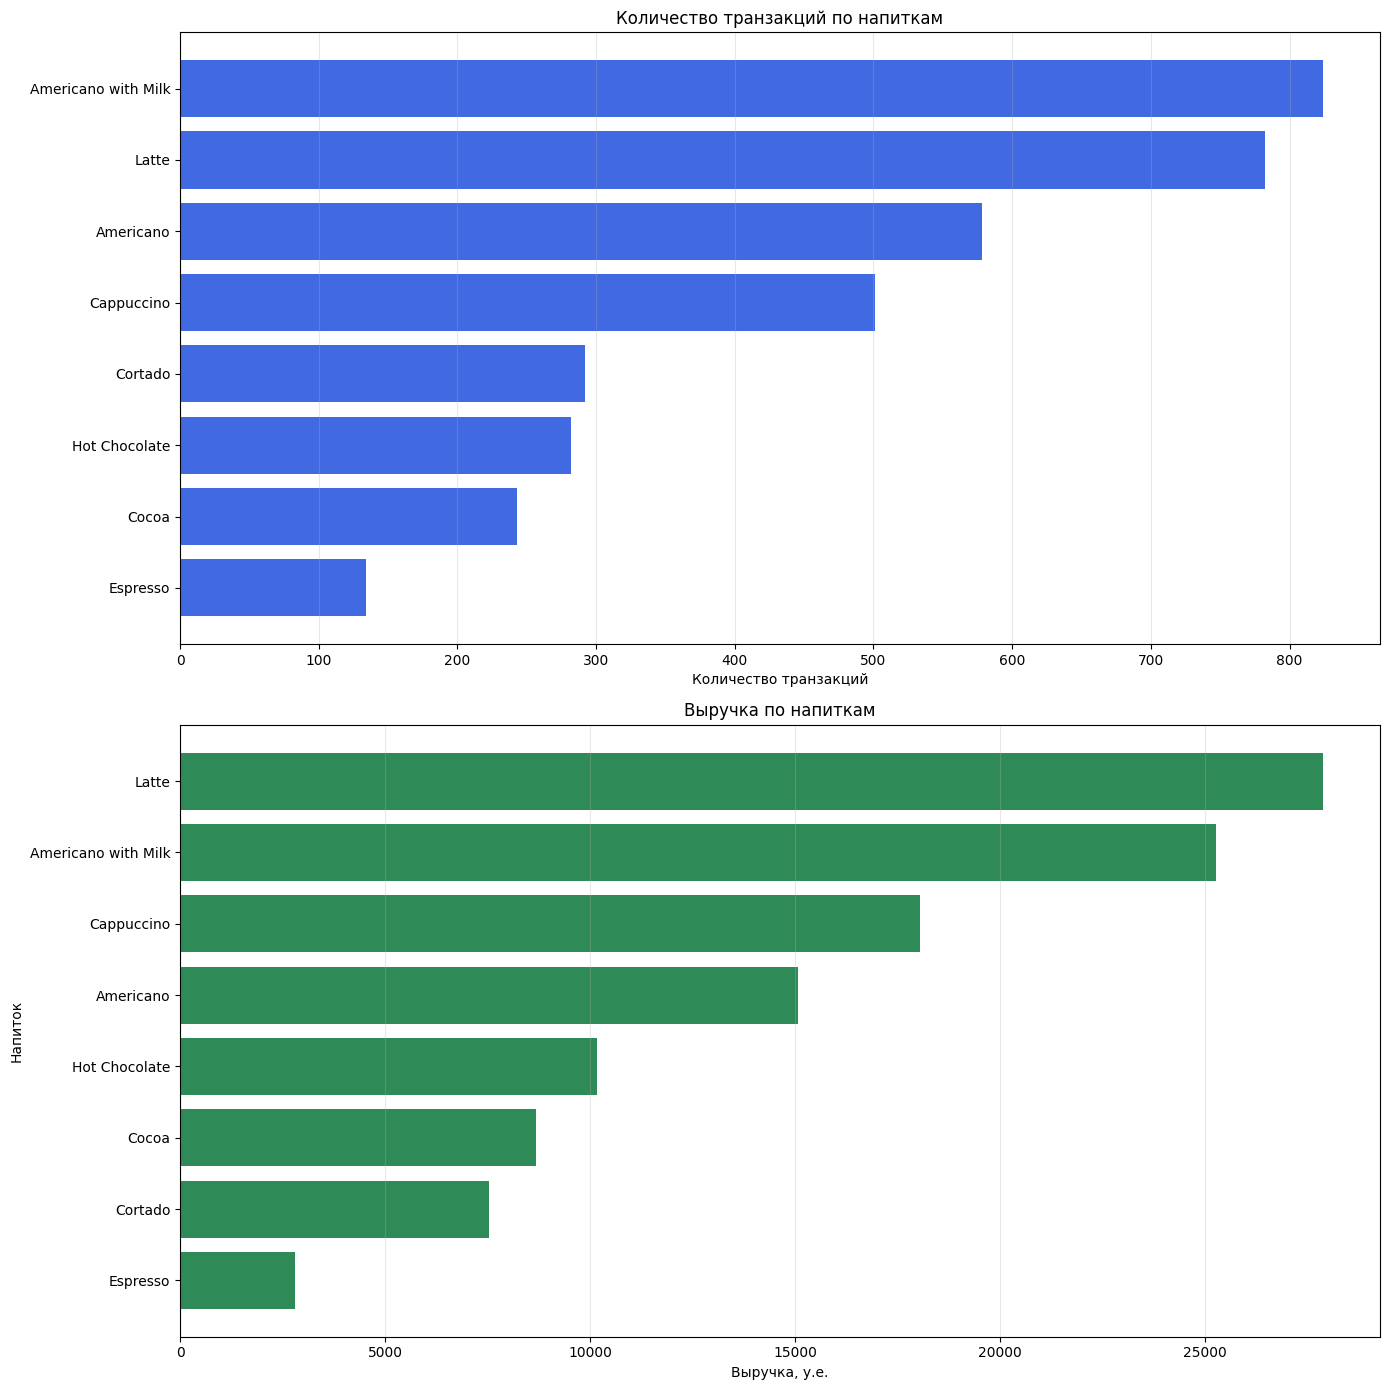

In [14]:
by_transactions=coffee_summary.sort_values('transactions')
by_revenue=coffee_summary.sort_values('revenue')

fig,axes=plt.subplots(2,1,figsize=(14,14))

axes[0].barh(
    by_transactions.index,
    by_transactions['transactions'],
    color='royalblue'
)
axes[0].set_title('Количество транзакций по напиткам')
axes[0].set_xlabel('Количество транзакций')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(
    by_revenue.index,
    by_revenue['revenue'],
    color='seagreen'
)
axes[1].set_title('Выручка по напиткам')
axes[1].set_xlabel('Выручка, у.е.')
axes[1].set_ylabel('Напиток')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

* самым популярным напитком по числу операций является Americano
with Milk: 824 транзакции, или около 22,7% всех операций;

* наибольшую выручку принёс Latte — 27 866,30 у. е.;
* лидер по числу операций и лидер по выручке не совпадают, поскольку суммы операций различаются между напитками;
* Espresso имеет наименьшие показатели как по числу операций, так и по выручке.

In [15]:
amount_levels = (
    df.groupby(['coffee_name', 'cash_type'])['money']
      .agg(
          transactions='size',
          unique_amounts=lambda x: sorted(x.unique())
      )
)
amount_levels

transactions               unique_amounts
coffee_name         cash_type                                           
Americano           card                564  [23.02, 25.96, 27.92, 28.9]
                    cash                 14                 [29.0, 30.0]
Americano with Milk card                809  [27.92, 30.86, 32.82, 33.8]
                    cash                 15                 [34.0, 35.0]
Cappuccino          card                486  [32.82, 35.76, 37.72, 38.7]
                    cash                 15                 [39.0, 40.0]
Cocoa               card                239  [32.82, 35.76, 37.72, 38.7]
                    cash                  4                 [39.0, 40.0]
Cortado             card                287  [23.02, 25.96, 27.92, 28.9]
                    cash                  5                       [30.0]
Espresso            card                129  [18.12, 21.06, 23.02, 24.0]
                    cash                  5                 [24.0, 25.0]
Hot Chocolate       card                276  [32.82, 35.76, 37.72, 38.7]
                    cash                  6                 [39.0, 40.0]
Latte               card                757  [32.82, 35.76, 37.72, 38.7]
                    cash                 25                 [39.0, 40.0]

> Для одних и тех же напитков зафиксированы разные уровни суммы
> операции. Наличные значения отличаются от карточных, при этом
> наличные представлены только 89 операциями и только до 3 июня 2024
> года. Поэтому дальнейшая временная динамика сумм исследуется
> отдельно для карточных операций.

In [16]:
card_amounts = (
    df.loc[
        df['cash_type'] == 'card',
        ['date', 'coffee_name', 'money']
    ]
    .drop_duplicates()
    .sort_values(['coffee_name', 'date', 'money'])
)

card_amounts.head()

,date,coffee_name,money
3,2024-03-01,Americano,28.9
11,2024-03-02,Americano,28.9
21,2024-03-03,Americano,28.9
42,2024-03-06,Americano,28.9
50,2024-03-07,Americano,28.9


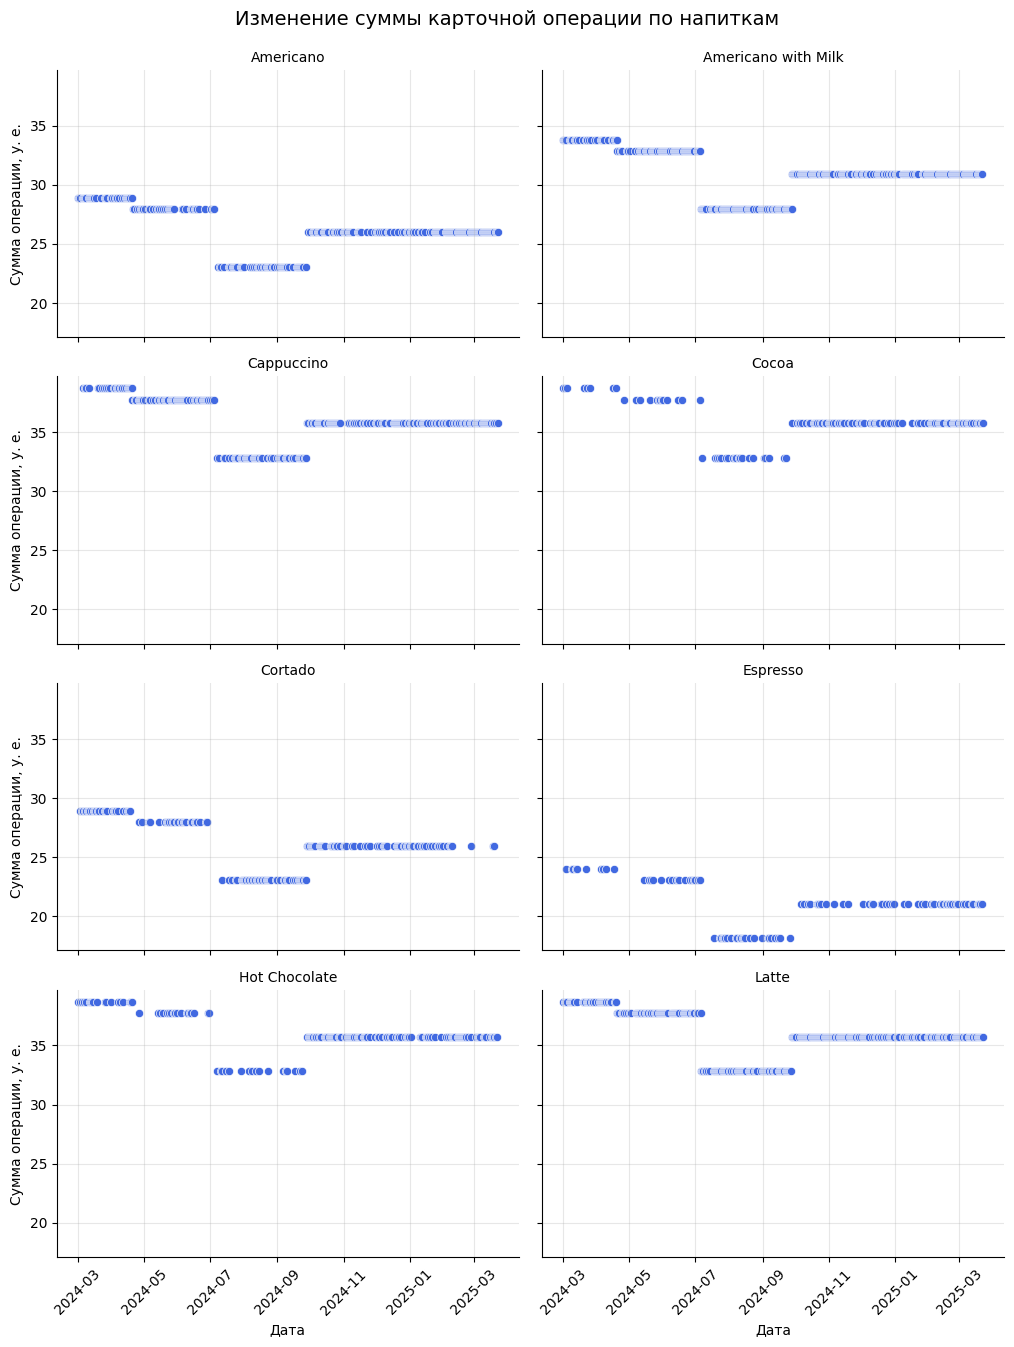

In [17]:
g = sns.relplot(
    data=card_amounts,
    x='date',
    y='money',
    col='coffee_name',
    col_wrap=2,
    kind='scatter',
    height=3.2,
    aspect=1.6,
    color='royalblue',
    s=35
)

g.set_titles('{col_name}')
g.set_axis_labels('Дата', 'Сумма операции, у. е.')

for ax in g.axes.flat:
  ax.tick_params(axis='x', rotation=45)
  ax.grid(alpha=0.3)

g.figure.suptitle(
  'Изменение суммы карточной операции по напиткам',
  y=1.02,
  fontsize=14
)

plt.show()

> Летом снижение общей средней суммы транзакции сопровождалось
> снижением карточных сумм для большинства напитков. Это указывает,
> что динамику нельзя объяснить только изменением структуры спроса.
> Возможное объяснение — изменение цен или правил расчёта суммы
> операции, однако установить точную причину по имеющимся данным
> невозможно.

In [18]:
monthly_coffee = (
    complete_months_df
    .groupby([
        pd.Grouper(key='date', freq='MS'),
        'coffee_name'
    ])
    .agg(transactions=('money', 'size'))
    .reset_index()
)
monthly_coffee['share_pct'] = (
    monthly_coffee['transactions']
    .div(
        monthly_coffee
        .groupby('date')['transactions']
        .transform('sum')
    )
    .mul(100)
)
coffee_share_pivot = (
    monthly_coffee
    .pivot(
        index='coffee_name',
        columns='date',
        values='share_pct'
    )
)

coffee_share_pivot.columns = (
  coffee_share_pivot.columns.strftime('%Y-%m')
)

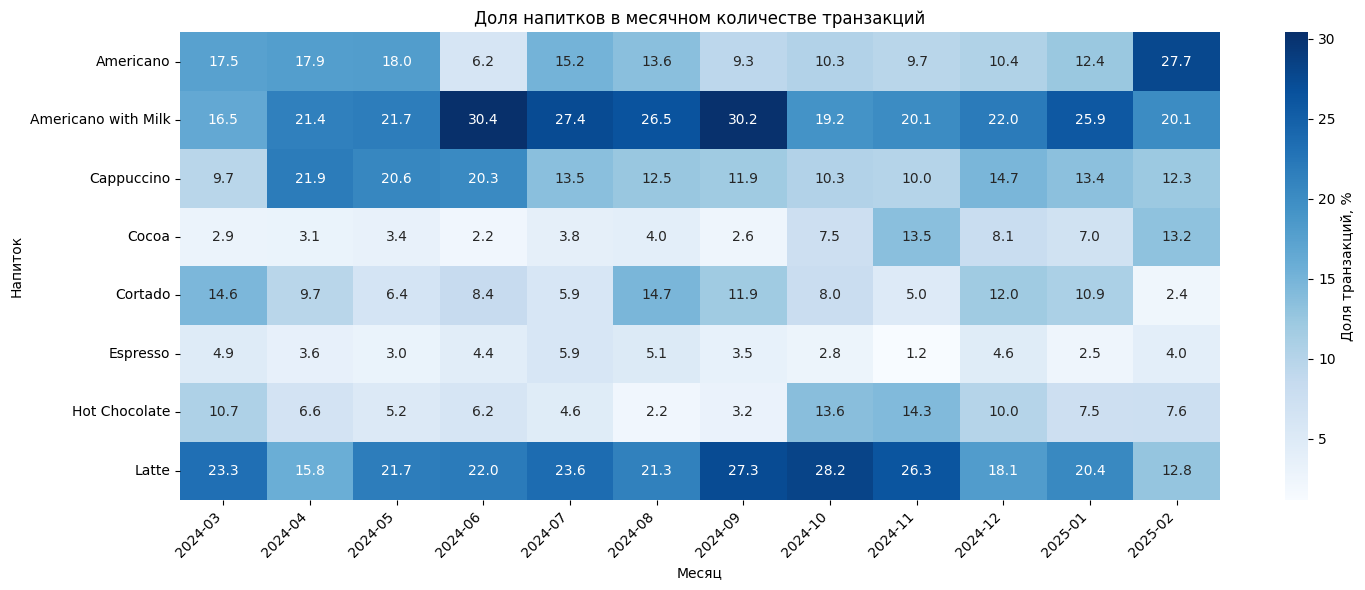

In [19]:
plt.figure(figsize=(15, 6))

sns.heatmap(
    coffee_share_pivot,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Доля транзакций, %'}
)

plt.title('Доля напитков в месячном количестве транзакций')
plt.xlabel('Месяц')
plt.ylabel('Напиток')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Americano with Milk и Latte в большинстве месяцев занимают высокую долю продаж, однако месячный лидер меняется;
* наиболее заметно менялась доля Americano: примерно от 6,2% до 27,7%;
* в феврале 2025 года Americano стал самым популярным напитком месяца;
* структура спроса не была постоянной и могла влиять на общую среднюю сумму операции;
* при этом летнее снижение карточных сумм наблюдалось у большинства
    напитков, поэтому изменение структуры спроса не было единственным
    фактором.

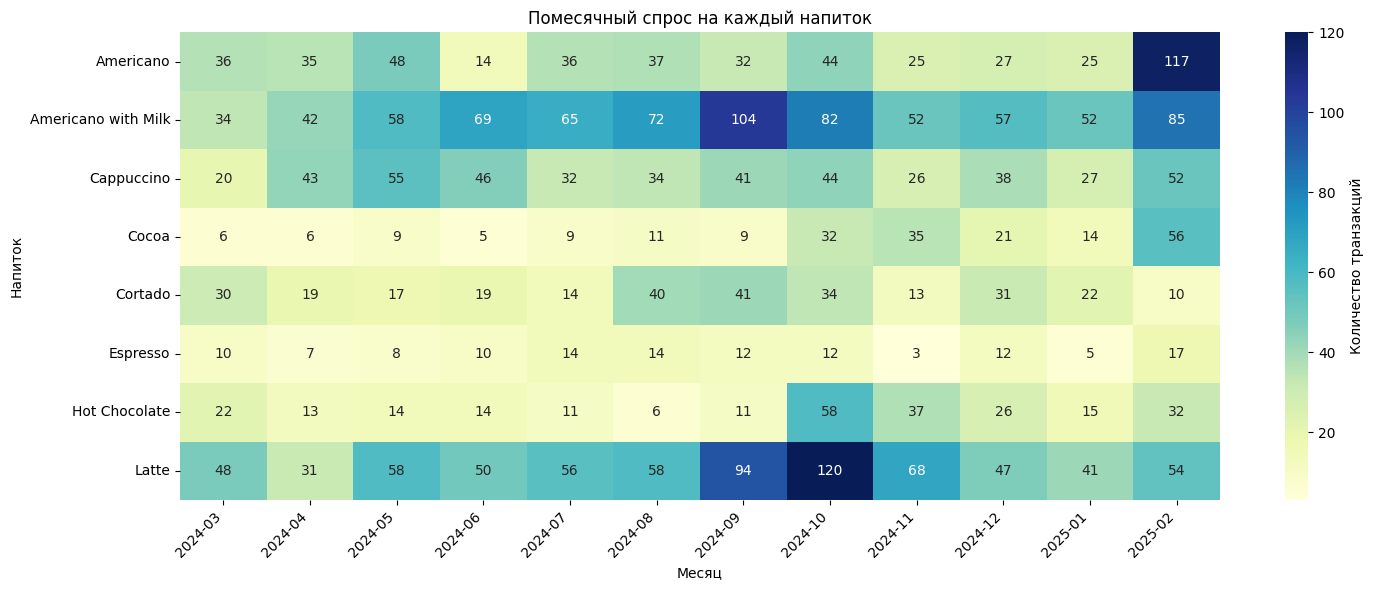

,coffee_name,month,transactions
0,Americano,2025-02,117
1,Americano with Milk,2024-09,104
2,Cappuccino,2024-05,55
3,Cocoa,2025-02,56
4,Cortado,2024-09,41
5,Espresso,2025-02,17
6,Hot Chocolate,2024-10,58
7,Latte,2024-10,120


In [20]:
absolute_monthly_demand = (
    monthly_coffee
    .pivot(index='coffee_name', columns='date', values='transactions')
    .fillna(0)
)
absolute_monthly_demand.columns = absolute_monthly_demand.columns.strftime('%Y-%m')

plt.figure(figsize=(15, 6))
sns.heatmap(
    absolute_monthly_demand,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Количество транзакций'}
)
plt.title('Помесячный спрос на каждый напиток')
plt.xlabel('Месяц')
plt.ylabel('Напиток')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

peak_demand = (
    monthly_coffee.loc[
        monthly_coffee.groupby('coffee_name')['transactions'].idxmax(),
        ['coffee_name', 'date', 'transactions']
    ]
    .sort_values('coffee_name')
    .reset_index(drop=True)
)
peak_demand['month'] = peak_demand['date'].dt.strftime('%Y-%m')
display(peak_demand[['coffee_name', 'month', 'transactions']])

**Выводы по абсолютному спросу на ассортимент:**

* спрос на разные напитки достигал максимума в разные месяцы, поэтому общая динамика продаж не описывает весь ассортимент одинаково;
* Americano with Milk достиг максимума в сентябре 2024 года — 104 операции, Latte в октябре — 120;
* максимумы Americano, Cocoa и Espresso пришлись на февраль 2025 года: 117, 56 и 17 операций соответственно;
* Cappuccino достиг максимума в мае 2024 года — 55 операций, Cortado в сентябре — 41, Hot Chocolate в октябре — 58;
* к февралю 2025 года спрос на Americano заметно вырос относительно начала наблюдений, тогда как спрос на Cortado снизился;
* месячные изменения являются описательными: без данных о доступности автомата, остатках и внешних факторах нельзя установить причины различий.

## 4. Временные закономерности спроса

Цель раздела — определить часы и дни недели с наиболее высокой интенсивностью зарегистрированных транзакций.

In [21]:
df['hour'] = df['datetime'].dt.hour

daily_hour = (
    df.pivot_table(
        index='date',
        columns='hour',
        values='datetime',
        aggfunc='count',
        fill_value=0
    )
    .reindex(index=calendar, columns=range(24), fill_value=0)
)

daily_hour.head()

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
2024-03-01,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,1,3,0,0,0,0
2024-03-02,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,0,0
2024-03-03,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,3,0,0,0,0,0
2024-03-04,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2024-03-05,0,0,0,0,0,0,0,0,0,1,...,1,0,0,6,1,0,0,0,0,0


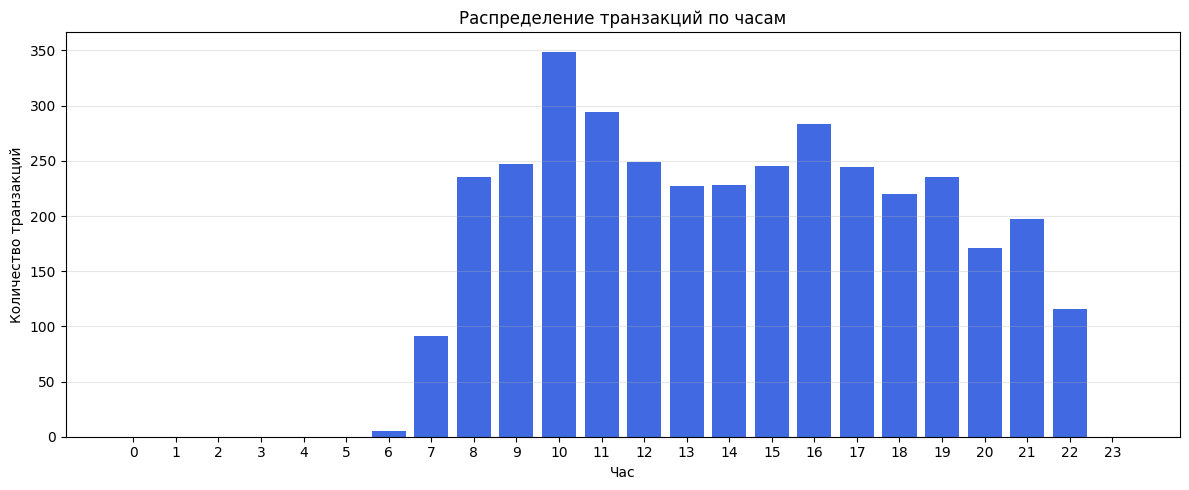

Пиковый час: 10:00 — 349 транзакций


In [22]:
hourly_transactions = daily_hour.sum(axis=0)

plt.figure(figsize=(12, 5))
plt.bar(hourly_transactions.index, hourly_transactions.values, color='royalblue')
plt.title('Распределение транзакций по часам')
plt.xlabel('Час')
plt.ylabel('Количество транзакций')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

peak_hour = hourly_transactions.idxmax()
peak_hour_transactions = hourly_transactions.max()
print(f'Пиковый час: {peak_hour}:00 — {peak_hour_transactions} транзакций')

,mean,median
Понедельник,10.20,10.0
Вторник,10.64,10.0
Среда,9.27,9.0
Четверг,9.45,9.0
Пятница,9.71,8.0
Суббота,8.61,8.0
Воскресенье,7.75,6.5


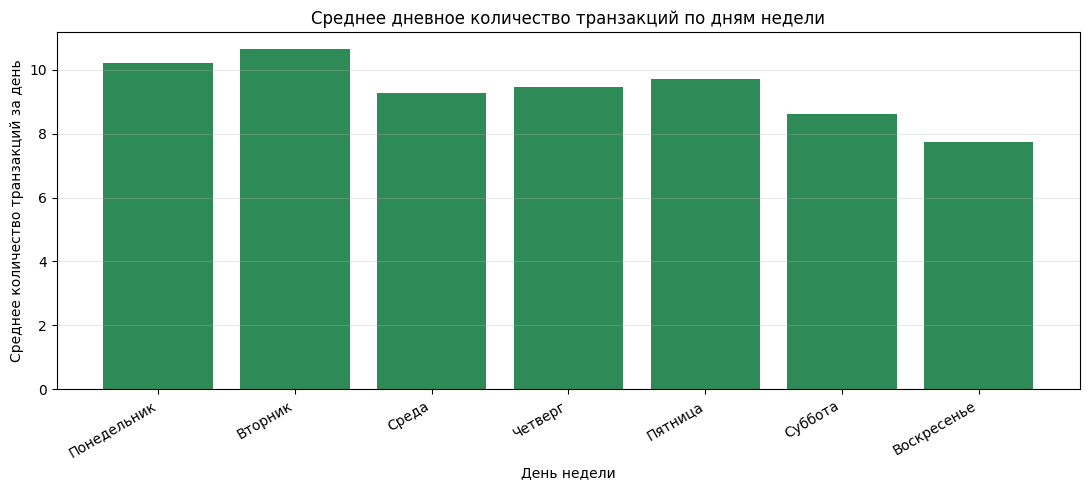

Максимальное среднее: Вторник — 10.64
Минимальное среднее: Воскресенье — 7.75


In [23]:
weekday_names = {0: 'Понедельник', 1: 'Вторник', 2: 'Среда', 3: 'Четверг', 4: 'Пятница', 5: 'Суббота', 6: 'Воскресенье'}

daily_transactions = daily_hour.sum(axis=1).rename('transactions').to_frame()
daily_transactions['weekday_num'] = daily_transactions.index.dayofweek
weekday_activity = (
    daily_transactions.groupby('weekday_num')['transactions']
    .agg(['mean', 'median']).reindex(range(7))
)
weekday_activity.index = [weekday_names[i] for i in weekday_activity.index]
display(weekday_activity.round(2))

plt.figure(figsize=(11, 5))
plt.bar(weekday_activity.index, weekday_activity['mean'], color='seagreen')
plt.title('Среднее дневное количество транзакций по дням недели')
plt.xlabel('День недели')
plt.ylabel('Среднее количество транзакций за день')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Максимальное среднее: {weekday_activity["mean"].idxmax()} — {weekday_activity["mean"].max():.2f}')
print(f'Минимальное среднее: {weekday_activity["mean"].idxmin()} — {weekday_activity["mean"].min():.2f}')

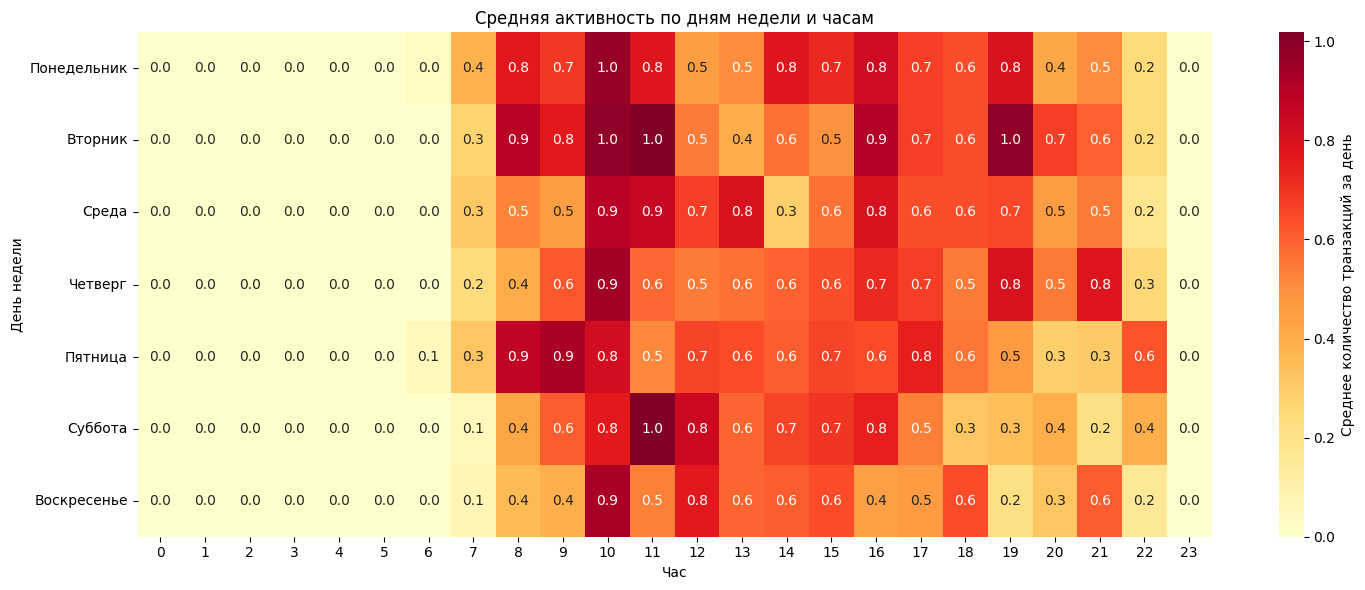

In [24]:
daily_hour_with_weekday = daily_hour.copy()
daily_hour_with_weekday['weekday_num'] = daily_hour_with_weekday.index.dayofweek
weekday_hour_average = (
    daily_hour_with_weekday.groupby('weekday_num')[list(range(24))]
    .mean().reindex(range(7))
)
weekday_hour_average.index = [weekday_names[i] for i in weekday_hour_average.index]

plt.figure(figsize=(15, 6))
sns.heatmap(weekday_hour_average, cmap='YlOrRd', annot=True, fmt='.1f',
            cbar_kws={'label': 'Среднее количество транзакций за день'})
plt.title('Средняя активность по дням недели и часам')
plt.xlabel('Час')

plt.ylabel('День недели')
plt.tight_layout()
plt.show()

**Выводы по временным закономерностям:**

* зарегистрированные операции встречаются с 06:00 до 22:59, однако по данным нельзя установить фактические часы доступности автомата;
* максимальное общее количество операций приходится на 10:00–10:59 — 349 транзакций;
* наибольшее среднее дневное число операций наблюдается во вторник — 10,64, наименьшее в воскресенье — 7,75;
* наиболее интенсивный период — вторник с 11:00 до 11:59: в среднем около 1,02 операции за соответствующий день;
* найденные различия описывают зарегистрированный спрос, но не позволяют установить их причины.

## 5. Способы оплаты

Цель раздела — сравнить зарегистрированные карточные и наличные операции с учётом того, что наличные представлены только в начале периода наблюдений.

In [25]:
cash_end_date = df.loc[df['cash_type'] == 'cash', 'date'].max()
common_payment_period = df[df['date'] <= cash_end_date]

payment_summary = (
    common_payment_period.groupby('cash_type')
    .agg(
        transactions=('money', 'size'),
        revenue=('money', 'sum'),
        average_transaction=('money', 'mean')
    )
)
payment_summary['transaction_share_pct'] = (
    payment_summary['transactions']
    .div(payment_summary['transactions'].sum())
    .mul(100)
)

display(payment_summary.round(2))
print(f'Последняя зарегистрированная наличная операция: {cash_end_date:%Y-%m-%d}')

,transactions,revenue,average_transaction,transaction_share_pct
cash_type,,,,
card,604,20499.48,33.94,87.16
cash,89,3186.00,35.80,12.84


Последняя зарегистрированная наличная операция: 2024-06-03


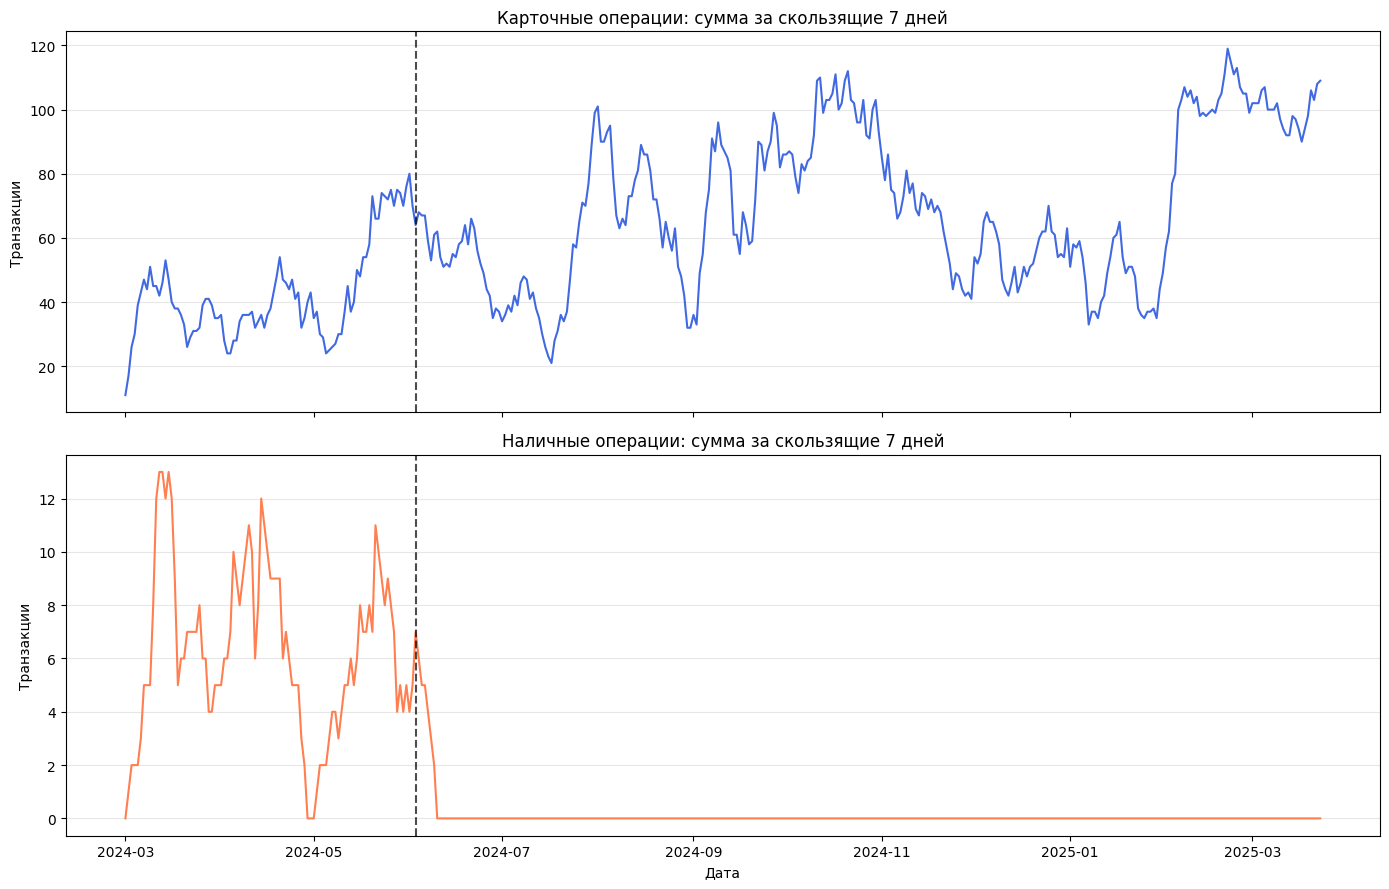

In [26]:
payment_daily = (
    df.pivot_table(
        index='date',
        columns='cash_type',
        values='datetime',
        aggfunc='count',
        fill_value=0
    )
    .reindex(index=calendar, columns=['card', 'cash'], fill_value=0)
)
payment_rolling_7d = payment_daily.rolling('7D', min_periods=1).sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(payment_rolling_7d.index, payment_rolling_7d['card'], color='royalblue')
axes[0].set_title('Карточные операции: сумма за скользящие 7 дней')
axes[0].set_ylabel('Транзакции')

axes[1].plot(payment_rolling_7d.index, payment_rolling_7d['cash'], color='coral')
axes[1].set_title('Наличные операции: сумма за скользящие 7 дней')
axes[1].set_ylabel('Транзакции')
axes[1].set_xlabel('Дата')

for ax in axes:
    ax.axvline(cash_end_date, color='black', linestyle='--', alpha=0.7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы по способам оплаты:**

* до последней зарегистрированной наличной операции включительно зафиксировано 604 карточные и 89 наличных операций;
* доля карточных операций в этом периоде составила 87,16%, наличных — 12,84%;
* после 3 июня 2024 года наличные операции в датасете отсутствуют, тогда как карточные продолжаются до конца наблюдений;
* средние суммы операций по способам оплаты нельзя интерпретировать как чистый эффект способа оплаты: различаются состав напитков, представленные периоды и уровни зарегистрированных сумм;
* по имеющимся данным нельзя определить, отражает исчезновение наличных реальное изменение работы автомата или изменение состава выгрузки.

## 6. Повторные операции по картам

Идентификатор карты позволяет приблизительно исследовать повторные покупки, но не равен идентификатору человека: одной картой могут пользоваться несколько людей, а один человек может использовать разные карты или наличные.

In [27]:
card_stats = (
    df.dropna(subset=['card'])
    .groupby('card')
    .agg(
        transactions=('money', 'size'),
        revenue=('money', 'sum'),
        first_purchase=('datetime', 'min'),
        last_purchase=('datetime', 'max')
    )
)

unique_cards = len(card_stats)
repeat_cards = card_stats['transactions'].gt(1).sum()
repeat_card_share = repeat_cards / unique_cards * 100
repeat_transaction_share = (
    card_stats.loc[card_stats['transactions'].gt(1), 'transactions'].sum()
    / card_stats['transactions'].sum() * 100
)

display(card_stats['transactions'].describe())
print(f'Уникальных идентификаторов карт: {unique_cards}')
print(f'Карт с повторными операциями: {repeat_cards} ({repeat_card_share:.1f}%)')
print(f'Доля операций по повторно встречавшимся картам: {repeat_transaction_share:.1f}%')

count    1316.000000
mean        2.695289
std         6.812804
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       129.000000
Name: transactions, dtype: float64

Уникальных идентификаторов карт: 1316
Карт с повторными операциями: 545 (41.4%)
Доля операций по повторно встречавшимся картам: 78.3%


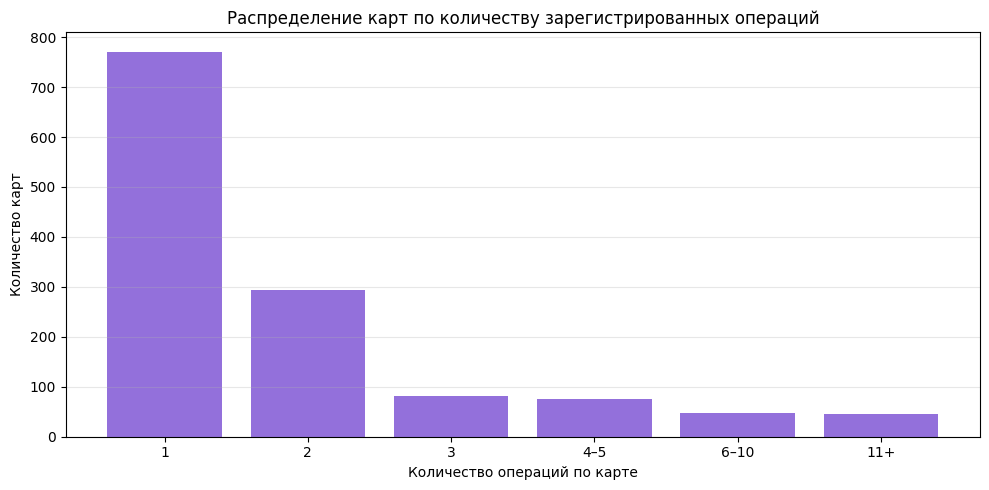

,cards
transactions,
1,771
2,294
3,82
4–5,75
6–10,48
11+,46


In [28]:
frequency_groups = pd.cut(
    card_stats['transactions'],
    bins=[0, 1, 2, 3, 5, 10, float('inf')],
    labels=['1', '2', '3', '4–5', '6–10', '11+']
)
frequency_distribution = frequency_groups.value_counts(sort=False)

plt.figure(figsize=(10, 5))
plt.bar(frequency_distribution.index.astype(str), frequency_distribution.values, color='mediumpurple')
plt.title('Распределение карт по количеству зарегистрированных операций')
plt.xlabel('Количество операций по карте')
plt.ylabel('Количество карт')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(frequency_distribution.rename('cards').to_frame())

**Выводы по повторным операциям:**

* в данных встречается 1 316 уникальных идентификаторов карт;
* 771 карта использована только в одной операции, медианное количество операций на карту также равно одной;
* 545 карт, или 41,4%, встречаются более одного раза;
* на повторно встречавшиеся карты приходится 78,3% всех карточных операций;
* максимальное число операций по одному идентификатору равно 129, что указывает на длинный правый хвост распределения и требует осторожной интерпретации;
* показатели описывают повторяемость идентификаторов карт, а не точное число покупателей или их лояльность.

## 7. Гипотезы для дальнейшего исследования

1. **Связь суммы операции и спроса.** Для каждого напитка проверить, отличается ли среднее недельное число карточных операций в течение четырёх недель до и после изменения уровня `money`. Ожидание: снижение суммы сопровождается ростом числа операций, но результат нельзя трактовать как причинный без контроля сезонности и доступности автомата.

2. **Различия реакции между напитками.** Сравнить относительное изменение недельного спроса после смены суммы операции для всех напитков. Ожидание: величина изменения неодинакова из-за различий в предпочтениях и исходном уровне суммы.

3. **Отложенная связь.** Проверить корреляцию между уровнем суммы и недельным спросом с лагами от одной до четырёх недель. Это позволит определить, сильнее ли совпадение в неделю изменения или проявляется позднее.

4. **Будни и выходные.** Проверить статистически, различается ли среднее дневного числа операций между буднями и выходными. Текущий описательный анализ указывает на более низкую активность в выходные.

5. **Повторные карты и ассортимент.** Сравнить структуру выбранных напитков у карт с одной операцией и у повторно встречавшихся карт. Ожидание: распределения напитков могут различаться, но карта не должна интерпретироваться как отдельный человек.

6. **Причина исчезновения наличных.** Проверить по журналам работы автомата или документации источника, связано ли отсутствие наличных после 3 июня 2024 года с отключением способа оплаты или изменением выгрузки. По текущему датасету эта гипотеза непроверяема.